# Technical Exercise
## Analysis and comparison of biosignals using different sensors

We have two datasets collected using distinct biomedical devices (`data` folder): `FPdata.xls` and `labchartdata.csv`

### Data Properties:
- `FPdata.xls`:
    - Recorded in a discontinuous manner with nonlinear sampling rate: time stamps correspond to detected start time of a beat;
    - Labeled based on the pressure stage during which the recording was made (Baseline, Stage1, Stage 2). It is not confirmed when the start and end of the FP recording was made relative to pressure chamber stage changes.
- `labchartdata.csv`:
    - Recorded continuously from start to finish with a sampling rate of 1000 Hz.
- Both:
    - Recordings do not necessarily have the same start time;
    - Common metric between 2 datasets: Heart rate (HR).

**Metrics to compare: Cardiac output (CO; `labchartdata.csv`) and Velocity time integral (VTI; `FPdata.xls`).**

In [1]:
import pandas as pd, numpy as np, os, sys
from scipy.interpolate import interp1d
from scipy import signal, stats
import matplotlib.pyplot as plt, seaborn as sns

sys.path.append(os.path.abspath(os.path.join("..")))
from src.loaders import load_data
from src.plotters import plot_HR_by_stage
from src.processors import get_running_time, get_stage_offset

fp_data, labchart_data = load_data('../data/')

## Exploratory Data Analysis / Pre-Processing
We are told that the `FPdata.xls` was recorded in a discontinuous manner with a non-linear sampling rate, and was labeled by stage. We can visualize this with our helper function (`src/plotters.py`). 

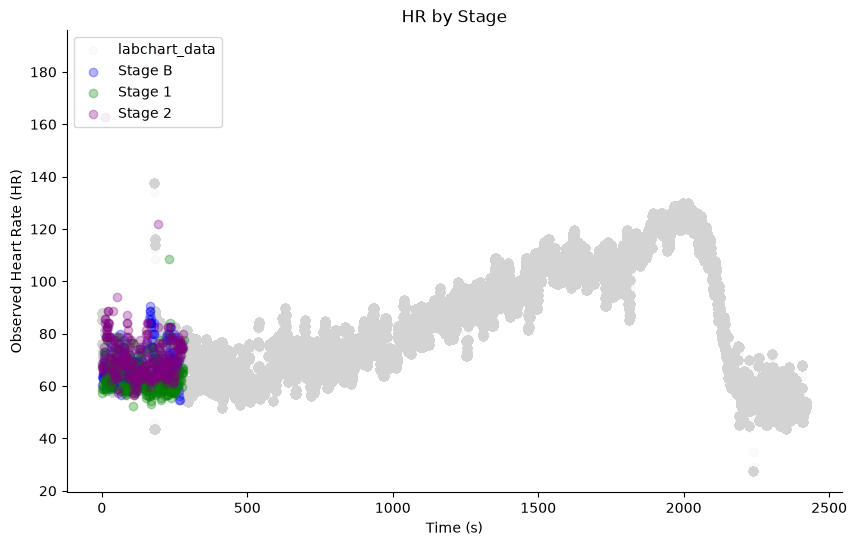

In [2]:
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Time (s)', hr_col='HR')  

It's clear that we need to fix the timeline for the measurements, as the clock restarts at each stage. It is not clear when the start/end of the recording happened relative to the stage changes, but as a first pass we can concatenate the three stages into one running timeline by offsetting each stage's time by the end of the previous one. 

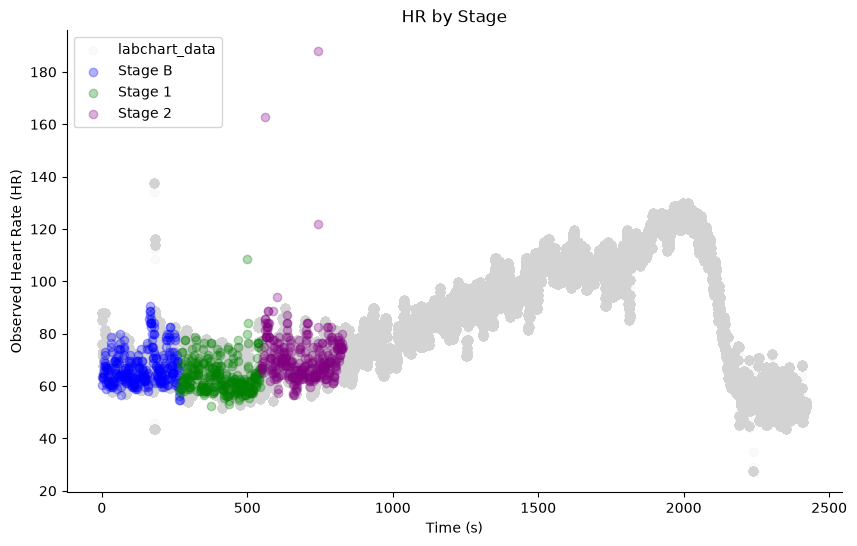

In [3]:
get_running_time(fp_data)
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR')

# sanity check
labchart_data.sort_values('TimeSec', inplace=True, ascending=True)
fp_data.sort_values('Corrected Time (s)', inplace=True, ascending=True)

Okay, this looks a little more like it! We still need to account for some offset between stages, but at least we have a continuous timeline. We also observe some (what look like) erroneous readings; we can consider outlier filtration on both datasets as a future step for tigher alignment and/or improved metric quantification/comparison. 

For now, we'll focus on determinging the stage-specific offsets. To do this, we will use cross-correlation, which is a technique used to measure the similarity of two signals by sliding one relative to the other. This can be visualized below (*[visual credit](https://medium.com/data-science/four-ways-to-quantify-synchrony-between-time-series-data-b99136c4a9c9)*).

How it works:

1. **Sliding Match:** A small template or signal moves step-by-step across another target signal or image.
2. **Similarity Score:** At each step, it calculates a value showing how closely the two shapes match.
3. **Peak Detection:** The highest peak in the output graph shows the exact point of best alignment or time delay (lag).

![Cross Correlation Visualized.](../data/assets/crosscorr.gif)

There is still the matter of non-linear sampling rates for the fp_data and overall differences in sampling frequency between fp_data and labchart_data. To handle this, we will resample both datasets to a consistent, shared frequency, with a preference for downsampling labchart_data versus upsampling fp_data (minimize artificial/interpolated data and lower computational cost).

Once both datasets are resampled, we will perform cross-correlation using the heart rate (HR) signal to determine the stage-specific offsets (`src/processors.py`).

In [4]:
stages = fp_data['Stage'].unique()
time_offsets = {stage: get_stage_offset(stage, fp_data, labchart_data) for stage in stages}

Stage: B
Stage window: 0.528 s to 267.903 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage B: 1.085 Hz
Using shared resample frequency: 1.085 Hz
Calculated Time Delay: 18.432 seconds
--------------------------------------------------
Stage: 1
Stage window: 268.616 s to 549.126 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage 1: 1.030 Hz
Using shared resample frequency: 1.030 Hz
Calculated Time Delay: 37.859 seconds
--------------------------------------------------
Stage: 2
Stage window: 549.138 s to 827.302 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage 2: 1.146 Hz
Using shared resample frequency: 1.146 Hz
Calculated Time Delay: 61.071 seconds
--------------------------------------------------


Now we can apply the stage-specific offsets to synchronize the signals.

In [ ]:
for stage, offset in time_offsets.items():
    mask = fp_data['Stage'] == stage
    fp_data.loc[mask, 'Corrected Time (s)'] = fp_data.loc[mask, 'Corrected Time (s)'] + offset

plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR')
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR', xlim=(0, 1000))    


That's more like it, woohoo! Now when we're looking at quantitative metrics from these datasets, it's more likely we're comparing apples with apples (so to speak).

Now we can approximate the labchart_data at the exact sampling times for fp_data for metric comparison.

In [ ]:
# resample the labchart_data to the same time base as the fp_data post-alignment
desired_time_base = fp_data['Corrected Time (s)'].values

labchart_sorted = labchart_data.sort_values('TimeSec').set_index('TimeSec')

labchart_data_resampled = pd.DataFrame({'TimeSec': desired_time_base})

for col in labchart_sorted.columns:
    if pd.api.types.is_numeric_dtype(labchart_sorted[col]):
        labchart_data_resampled[col] = np.interp(
            desired_time_base,
            labchart_sorted.index.to_numpy(),
            labchart_sorted[col].to_numpy()
        )

In [ ]:
# compute the correlation between the CO values and the Vmax VTI Total values from fp_data_aligned
corr_coeff = np.corrcoef(labchart_data_resampled['CO'], fp_data['Vmax VTI Total'])[0, 1]

# stage-specific correlation analysis
stages = fp_data['Stage'].unique()
stage_correlations = {}
for stage in stages:
    mask = fp_data['Stage'] == stage
    stage_fp_data = fp_data[mask]
    stage_labchart_data = labchart_data_resampled[mask]
    
    if not stage_fp_data.empty and not stage_labchart_data.empty:
        corr_coeff_stage = np.corrcoef(stage_labchart_data['CO'], stage_fp_data['Vmax VTI Total'])[0, 1]
        stage_correlations[stage] = corr_coeff_stage
    else:
        stage_correlations[stage] = None


# output a table summarizing the correlation coefficients for each stage with significance testing
correlation_summary = pd.DataFrame.from_dict(stage_correlations, orient='index', columns=['Correlation Coefficient'])
correlation_summary.index.name = 'Stage'
correlation_summary['P-Value'] = correlation_summary['Correlation Coefficient'].apply(lambda x: None if pd.isnull(x) else stats.pearsonr(labchart_data_resampled['CO'], fp_data['Vmax VTI Total'])[1] if not pd.isnull(x) else None)

In [ ]:
# join the two datasets and look at the pairplot
merged_data = pd.merge(labchart_data_resampled, fp_data, left_on='TimeSec', right_on='Corrected Time (s)', how='inner')
merged_data.columns
# sns.pairplot(merged_data)

In [ ]:
# # Adaptive, robust HR outlier filtering using rolling median +/- k*MAD
# def _infer_window_size(n, min_window=25, max_fraction=0.10, scale=4.0):
#     if n <= 0:
#         return 1
#     if n <= min_window:
#         return n
#     upper = max(min_window, int(n * max_fraction))
#     proposed = int(scale * np.sqrt(n))
#     return int(np.clip(proposed, min_window, upper))

# def _rolling_hr_robust_stats(df, hr_col='HR', window_size=None, std_devs=3.5, mad_scale=1.4826):
#     n = len(df)
#     effective_window = _infer_window_size(n) if window_size is None else min(int(window_size), max(n, 1))
#     hr = df[hr_col].astype(float)

#     # Robust center estimate
#     hr_median = hr.rolling(window=effective_window, min_periods=1).median()

#     # Robust spread estimate: MAD, scaled to approximate standard deviation
#     abs_dev = (hr - hr_median).abs()
#     hr_mad = abs_dev.rolling(window=effective_window, min_periods=1).median()
#     hr_scale = mad_scale * hr_mad

#     # Avoid zero-width bands in flat regions
#     positive_scale = hr_scale[hr_scale > 0]
#     fallback_scale = positive_scale.median() if not positive_scale.empty else 1.0
#     hr_scale = hr_scale.where(hr_scale > 0, fallback_scale)

#     lower = hr_median - std_devs * hr_scale
#     upper = hr_median + std_devs * hr_scale
#     mask = hr.between(lower, upper)
#     return hr_median, hr_scale, mask, effective_window

# def filter_hr_outliers(df, hr_col='HR', window_size=None, std_devs=3):
#     hr_center, hr_scale, mask, effective_window = _rolling_hr_robust_stats(
#         df, hr_col=hr_col, window_size=window_size, std_devs=std_devs
#     )
#     filtered_data = df.loc[mask].copy()
#     return filtered_data, hr_center, hr_scale, mask, effective_window

# def _plot_removals(df, time_col, hr_col='HR', window_size=None, std_devs=3, ax=None, title=None):
#     hr_center, hr_scale, mask, effective_window = _rolling_hr_robust_stats(
#         df, hr_col=hr_col, window_size=window_size, std_devs=std_devs
#     )

#     if ax is None:
#         fig, ax = plt.subplots(figsize=(8,3))
#     ax.scatter(df.loc[mask, time_col], df.loc[mask, hr_col], s=1, c='tab:blue', label='kept', alpha=0.6)
#     ax.scatter(df.loc[~mask, time_col], df.loc[~mask, hr_col], s=6, c='red', label='removed', alpha=0.8)
#     ax.set_xlabel(time_col)
#     ax.set_ylabel(hr_col)
#     if title:
#         ax.set_title(f"{title} (MAD, window={effective_window})")
#     sns.despine()
#     ax.legend()

# # Quick visualization of candidate removals for both datasets using auto window sizing
# fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)
# _plot_removals(labchart_data, 'TimeSec', 'HR', window_size=None, std_devs=3, ax=axes[0], title='labchart_data HR')
# _plot_removals(fp_data, 'Corrected Time (s)', 'HR', window_size=None, std_devs=3, ax=axes[1], title='fp_data HR')
# plt.tight_layout()

# std_devs = 3

# filtered_labchart_data, hr_mean, hr_std, mask, labchart_window = filter_hr_outliers(
#     labchart_data, hr_col='HR', window_size=None, std_devs=std_devs
# )

# filtered_fp_data, fp_hr_mean, fp_hr_std, fp_mask, fp_window = filter_hr_outliers(
#     fp_data, hr_col='HR', window_size=None, std_devs=std_devs
# )

# print(f"Auto-selected MAD windows -> labchart: {labchart_window}, fp: {fp_window}")